# **Practical Q3: Naive Bayes + Logestic Regression**

### Import Libraries

In [2]:
# Improting needed libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42



---


## Part (a)
### Load Digits Dataset + Train/Test Split (70/30 Stratified)

In [3]:
digits = load_digits()
X = digits.data          # shape: (n_samples, 64)
y = digits.target        # shape: (n_samples,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class ratio (sample):", np.bincount(y_train)[:5], "...")

Train: (1257, 64)  Test: (540, 64)
Train class ratio (sample): [124 127 124 128 127] ...


### Standard Scaling (Fit on Train, Transform Train/Test)

In [4]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

### GaussianNB on Raw Features (64) + Evaluation

GaussianNB (Raw) Test Accuracy: 0.7722222222222223


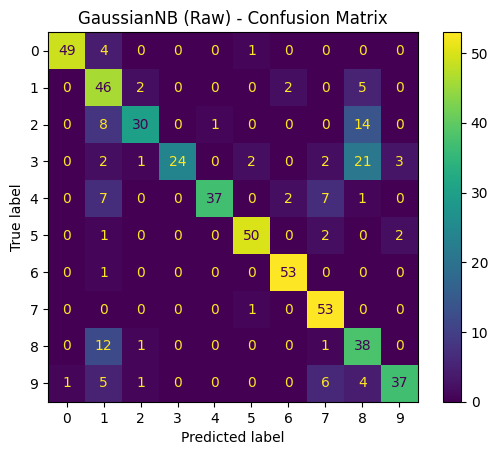

In [5]:
gnb_raw = GaussianNB()
gnb_raw.fit(X_train_sc, y_train)

y_pred_gnb_raw = gnb_raw.predict(X_test_sc)

acc_gnb_raw = accuracy_score(y_test, y_pred_gnb_raw)
cm_gnb_raw = confusion_matrix(y_test, y_pred_gnb_raw)

print("GaussianNB (Raw) Test Accuracy:", acc_gnb_raw)

disp = ConfusionMatrixDisplay(cm_gnb_raw)
disp.plot(values_format="d")
plt.title("GaussianNB (Raw) - Confusion Matrix")
plt.show()

### Logistic Regression (multinomial, saga) + GridSearch(C) + Evaluation

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best LR Params (Raw): {'C': 5}
Best LR CV Accuracy (Raw): 0.9642035034465313
Logistic Regression (Raw) Test Accuracy: 0.9722222222222222


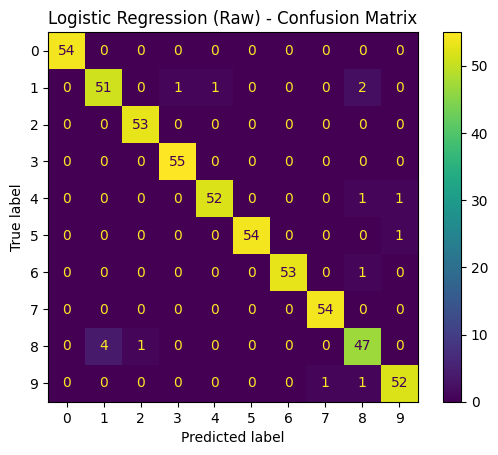

In [6]:
lr = LogisticRegression(
    multi_class="multinomial",
    solver="saga",
    max_iter=5000,
    random_state=RANDOM_STATE
)

param_grid_lr = {"C": [0.1, 1, 5]}

lr_grid_raw = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid_raw.fit(X_train_sc, y_train)

print("Best LR Params (Raw):", lr_grid_raw.best_params_)
print("Best LR CV Accuracy (Raw):", lr_grid_raw.best_score_)

best_lr_raw = lr_grid_raw.best_estimator_
y_pred_lr_raw = best_lr_raw.predict(X_test_sc)

acc_lr_raw = accuracy_score(y_test, y_pred_lr_raw)
cm_lr_raw = confusion_matrix(y_test, y_pred_lr_raw)

print("Logistic Regression (Raw) Test Accuracy:", acc_lr_raw)

disp = ConfusionMatrixDisplay(cm_lr_raw)
disp.plot(values_format="d")
plt.title("Logistic Regression (Raw) - Confusion Matrix")
plt.show()



---


# Part B

### PCA (95% Variance) Fit on Train + Transform Train/Test


In [7]:
pca = PCA(n_components=0.95, svd_solver="full", random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print("Original dim:", X_train_sc.shape[1], " -> PCA dim:", X_train_pca.shape[1])
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

Original dim: 64  -> PCA dim: 39
Explained variance ratio sum: 0.9520063658369052


### GaussianNB with PCA + Evaluation

GaussianNB (PCA) Test Accuracy: 0.9203703703703704


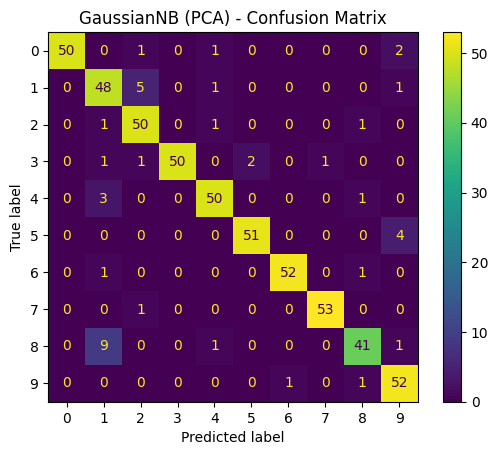

In [8]:
gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca, y_train)

y_pred_gnb_pca = gnb_pca.predict(X_test_pca)

acc_gnb_pca = accuracy_score(y_test, y_pred_gnb_pca)
cm_gnb_pca = confusion_matrix(y_test, y_pred_gnb_pca)

print("GaussianNB (PCA) Test Accuracy:", acc_gnb_pca)

disp = ConfusionMatrixDisplay(cm_gnb_pca)
disp.plot(values_format="d")
plt.title("GaussianNB (PCA) - Confusion Matrix")
plt.show()

### Logistic Regression with PCA + GridSearch(C) + Evaluation

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best LR Params (PCA): {'C': 0.1}
Best LR CV Accuracy (PCA): 0.9586353000695631
Logistic Regression (PCA) Test Accuracy: 0.9592592592592593


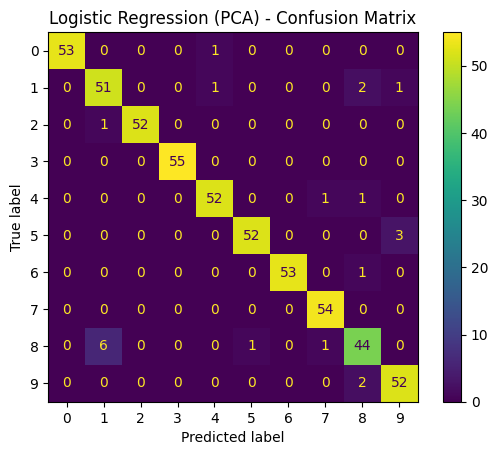

In [9]:
lr_grid_pca = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid_pca.fit(X_train_pca, y_train)

print("Best LR Params (PCA):", lr_grid_pca.best_params_)
print("Best LR CV Accuracy (PCA):", lr_grid_pca.best_score_)

best_lr_pca = lr_grid_pca.best_estimator_
y_pred_lr_pca = best_lr_pca.predict(X_test_pca)

acc_lr_pca = accuracy_score(y_test, y_pred_lr_pca)
cm_lr_pca = confusion_matrix(y_test, y_pred_lr_pca)

print("Logistic Regression (PCA) Test Accuracy:", acc_lr_pca)

disp = ConfusionMatrixDisplay(cm_lr_pca)
disp.plot(values_format="d")
plt.title("Logistic Regression (PCA) - Confusion Matrix")
plt.show()



---

# Part C

### Compare All 4 Settings (Summary Table)

In [ ]:
results = pd.DataFrame({
    "Model": ["GaussianNB (Raw)", "Logistic (Raw)", "GaussianNB (PCA)", "Logistic (PCA)"],
    "Test Accuracy": [acc_gnb_raw, acc_lr_raw, acc_gnb_pca, acc_lr_pca]
})

results

### Short Analysis Helper (Optional: Accuracy Differences)

In [11]:
delta_gnb = acc_gnb_pca - acc_gnb_raw
delta_lr  = acc_lr_pca  - acc_lr_raw

print("Delta Accuracy (GNB: PCA - Raw):", delta_gnb)
print("Delta Accuracy (LR : PCA - Raw):", delta_lr)

Delta Accuracy (GNB: PCA - Raw): 0.14814814814814814
Delta Accuracy (LR : PCA - Raw): -0.012962962962962954
